In [1]:
import numpy as np 
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import json

from datetime import datetime
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson
from pycorr import TwoPointEstimator

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.sgp as sgp

In [ ]:
importlib.reload(inference)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

do_phot_correction = True
do_spec_correction = True

In [ ]:
zvals, wsp_meas_a, wsp_err_a, wss_meas_a, wss_err_a, npz_a, npz_err_a = ({k: [] for k in [1, 2, 3, 4]} for _ in range(7))

for tomo in [1, 2, 3, 4]:
    tomo_to_tracer = {
        1 : ['BGS_ANY', 'LRG', 'ELG_LOPnotqso'],
        2 : ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO'],
        3 : ['LRG', 'ELGnotqso', 'QSO'],
        4 : ['LRG', 'ELGnotqso', 'QSO'],
    }
    stem = 'dr2' if tomo == 3 or tomo == 4 else 'dr1'
    patches = [1,2,3,4]
    path_dictionary = {
        'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # unused in practice 
        'DESI_NGC' : ROOT / stem / f'autos_NGC',
        'DESI_SGC' : ROOT / stem / f'autos_SGC',
        'DESIxHSC' : ROOT / stem / f'cross',
    }
    fr = cf.CorrFileReader(path_dictionary['DESIxHSC'])
    colors_tomo = np.random.choice(['grey', 'blue', 'green'], size=len(tomo_to_tracer[tomo]), replace=False)
    for tracer, color in zip(tomo_to_tracer[tomo], colors_tomo):
        zbins = fr.get_bins(tracer)
        wsp_meas, wsp_err, wss_meas, wss_err, deltaz, zloc, result, combined_err = inference.full_npz_tomo(
            path_dictionary=path_dictionary,
            do_phot_correction=do_phot_correction,
            do_spec_correction=do_spec_correction,
            scale_cuts=scale_cut,
            tomo_bin=tomo,
            tracer=tracer,
            which_patches=patches,
            return_chunks=True,
        )
        _zvals = (zbins[:-1] + zbins[1:]) / 2
        zvals[tomo].append(_zvals)
        npz_a[tomo].append(result)
        npz_err_a[tomo].append(combined_err)
        wsp_meas_a[tomo].append(wsp_meas)
        wsp_err_a[tomo].append(wsp_err)
        wss_meas_a[tomo].append(wss_meas)
        wss_err_a[tomo].append(wss_err)

In [ ]:
tomo=1
for tracer_id in [0, 1, 2]:
    tracer = tomo_to_tracer[tomo][tracer_id]
    plt.errorbar(zvals[tomo][tracer_id], wsp_meas_a[tomo][tracer_id]/0.05, yerr=wsp_err_a[tomo][tracer_id]/0.05, fmt='v', color='red', label='Meas ' + tracer, capsize=3, linestyle='--')
    plt.errorbar(zvals[tomo][tracer_id], npz_a[tomo][tracer_id], yerr=npz_err_a[tomo][tracer_id], fmt='+', color='green', label='n(z) ' + tracer, capsize=3, linestyle=':')
    plt.errorbar(zvals[tomo][tracer_id], np.sqrt(wss_meas_a[tomo][tracer_id]), yerr=wss_err_a[tomo][tracer_id]/(2*np.sqrt(wss_meas_a[tomo][tracer_id])), fmt='o', color='blue', label='SS ' + tracer, capsize=3, linestyle='-.')

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('n(z)')
plt.legend()
plt.title(f'Area : {patches} - [{scale_cut[0]} < r < {scale_cut[1]}] h^-1 Mpc')
plt.xlim(0.5, 2.1)

In [61]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

RESULTS_ROOT = 'results/'
Path(RESULTS_ROOT).mkdir(parents=True, exist_ok=True)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}
stem = 'dr2'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # unused in practice 
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
fr = cf.CorrFileReader(path_dictionary['DESIxHSC'])

In [62]:
## precompute w_dm
import scipy.interpolate as interp
scale_cut = [1, 5]
bins_z_spectro = inference._get_fine_redshift_bins(
    fr=fr,
    tracer='Merged'
)
vals_z_spectro = (bins_z_spectro[:-1] + bins_z_spectro[1:]) / 2
print(f'Scale cuts: {scale_cut}')
vals_z_wdm = np.linspace(0.01, 3, 150)
rp_wdm = np.linspace(scale_cut[0], scale_cut[1], 100)
wdm_values = np.array([
    ct.w_dm(
        rp_vals=rp_wdm,
        z=z,
        integrate=True
        )
    for z in vals_z_wdm
])
wdm_interpolator = interp.interp1d(
    vals_z_wdm, 
    wdm_values, 
    bounds_error=False, 
    fill_value='extrapolate'
)

Scale cuts: [1, 5]


In [63]:
importlib.reload(inference)
importlib.reload(ct)
print('\nScale cuts : ', scale_cut, '\n')

npzs = [{k: [] for k in [1, 2, 3, 4]} for _ in range(4)] # no correction, only spec, both spec and bias, both spec & bias & mag
npz_errs = [{k: [] for k in [1, 2, 3, 4]} for _ in range(4)]
zvals = [{k: [] for k in [1, 2, 3, 4]} for _ in range(4)]

for ic, condition in enumerate([
    (False, False, False), # no correction
    (False, True, False), # only spec correction
    (True, True, False), # with bias and spec correction
    (True, True, True), # with magnification
]):
    do_phot_correction, do_spec_correction, do_mag = condition
    for tomo in [1, 2, 3, 4]:
        tomo_to_tracer = {
            1 : ['BGS_ANY', 'LRG', 'ELG_LOPnotqso'],
            2 : ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO'],
            3 : ['LRG', 'ELGnotqso', 'QSO'],
            4 : ['LRG', 'ELGnotqso', 'QSO'],
        }
        stem = 'dr2' if tomo == 3 or tomo == 4 else 'dr1'
        patches = [1,2,3,4]
        path_dictionary = {
            'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # unused in practice 
            'DESI_NGC' : ROOT / stem / f'autos_NGC',
            'DESI_SGC' : ROOT / stem / f'autos_SGC',
            'DESIxHSC' : ROOT / stem / f'cross',
            'MergedxMerged' : ROOT / f'merged_{stem}', 
            'MergedxHSC' : ROOT / f'merged_{stem}'
        }
        fr = cf.CorrFileReader(path_dictionary['DESIxHSC'])
        if (condition == (False, False, False)):
            # we fuse estimators for the no correction case because of amplitude differences for each tracer... 
            # just makes it easier to compare
            meas = inference.full_npz_tomo(
                path_dictionary=path_dictionary,
                do_phot_correction=do_phot_correction,
                do_spec_correction=do_spec_correction,
                scale_cuts=scale_cut,
                tomo_bin=tomo,
                tracer='Merged',
                which_patches=None,
                precomp_wdm=wdm_interpolator,
            )
            npzs[ic][tomo].append(meas[0])  
            npz_errs[ic][tomo].append(meas[1])
            zbins = inference._get_fine_redshift_bins(fr, tracer='Merged')
            _zvals = (zbins[:-1] + zbins[1:]) / 2
            zvals[ic][tomo].append(_zvals)
        else:
            for ind, tracer in enumerate(tomo_to_tracer[tomo]):
                
                zbins = fr.get_bins(tracer)
                _zvals = (zbins[:-1] + zbins[1:]) / 2
                meas = inference.full_npz_tomo(
                    path_dictionary=path_dictionary,
                    do_phot_correction=do_phot_correction,
                    do_spec_correction=do_spec_correction,
                    scale_cuts=scale_cut,
                    tomo_bin=tomo,
                    tracer=tracer,
                    which_patches=patches,
                    precomp_wdm=wdm_interpolator,
                )
                if do_mag == True:
                    _npz, _npz_err, wdm, Mag, dMag = ct.solve_magnification(
                        meas=meas,
                        tracer=tracer,
                        tomo_bin=tomo,
                        scale_cut=scale_cut,
                        zvalues=_zvals,
                        return_matrices=True 
                    )
                    meas = (_npz, _npz_err)
                    
                zvals[ic][tomo].append(_zvals)
                npzs[ic][tomo].append(meas[0])  
                npz_errs[ic][tomo].append(meas[1])


Scale cuts :  [1, 5] 

Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Using standard method for tracer BGS_ANY and tomo bin 1.
Using standard method for tracer LRG and tomo bin 1.
Using standard method for tracer ELG_LOPnotqso and tomo bin 1.
Using standard method for tracer BGS_ANY and tomo bin 2.
Using standard method for tracer LRG and tomo bin 2.
Using standard method for tracer ELG_LOPnotqso and tomo bin 2.
Using standard method for tracer QSO and tomo bin 2.
Using standard method for tracer LRG and tomo bin 3.
Using standard method for tracer ELGnotqso and tomo bin 3.
Using standard method for tracer QSO and tomo bin 3.
Using standard method for tracer LRG and tomo bin 4.
Using standard method for tracer ELGnotqso and tomo bin 4.
Using standard method for tracer QSO and tomo bin 4.
Using standard method for trace

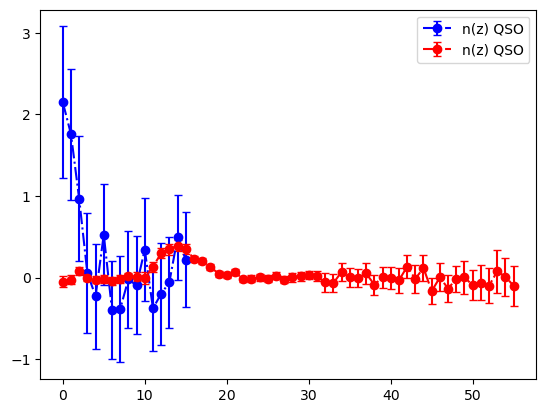

In [64]:
plt.errorbar(x=np.arange(len(npzs[3][2][2])), y=npzs[3][2][2], yerr=npz_errs[3][2][2], fmt='o', color='blue', label='n(z) ' + tracer, capsize=3, linestyle='-.')
plt.errorbar(x=np.arange(len(npzs[0][2][0])), y=npzs[0][2][0], yerr=npz_errs[0][2][0], fmt='o', color='red', label='n(z) ' + tracer, capsize=3, linestyle='-.')
plt.legend()

In [65]:
RESULTS_ROOT = 'results/'
Path(RESULTS_ROOT).mkdir(parents=True, exist_ok=True)
data_rows = []

tomo_to_tracer = {
    1 : ['BGS_ANY', 'LRG', 'ELG_LOPnotqso'],
    2 : ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO'],
    3 : ['LRG', 'ELGnotqso', 'QSO'],
    4 : ['LRG', 'ELGnotqso', 'QSO'],
}

for tomo in [1, 2, 3, 4]:
    # --- "Merged" cases (cross)
    z_vals_cross = zvals[0][tomo][0]
    nz_cross = npzs[0][tomo][0]
    nz_cross_err = npz_errs[0][tomo][0]

    for j in range(len(z_vals_cross)):
        data_rows.append({
            'tomo_bin': tomo,
            'tracer': 'Merged',
            'redshift': z_vals_cross[j],
            'npz_cross': nz_cross[j],
            'npz_cross_err': nz_cross_err[j],
            'npz_bs_bp': None,
            'npz_bs_bp_err': None,
            'npz_bs_bp_mag': None,
            'npz_bs_bp_mag_err': None
        })

    # --- per-tracer cases (bs_bp & bs_bp_mag)
    for i, tracer in enumerate(tomo_to_tracer[tomo]):
        z_vals_bs = zvals[1][tomo][i]
        nz_bs = npzs[1][tomo][i]
        nz_bs_err = npz_errs[1][tomo][i]

        z_vals_bp = zvals[2][tomo][i]
        nz_bs_bp = npzs[2][tomo][i]
        nz_bs_bp_err = npz_errs[2][tomo][i]

        z_vals_bp_mag = zvals[3][tomo][i]
        nz_bs_bp_mag = npzs[3][tomo][i]
        nz_bs_bp_mag_err = npz_errs[3][tomo][i]

        # sanity check: bp and bp_mag z-grids should match
        assert np.allclose(z_vals_bp, z_vals_bp_mag)

        for j in range(len(z_vals_bp)):
            data_rows.append({
                'tomo_bin': tomo,
                'tracer': tracer,
                'redshift': z_vals_bp[j],
                'npz_cross': None,
                'npz_cross_err': None,
                'npz_bs': nz_bs[j],
                'npz_bs_err': nz_bs_err[j],
                'npz_bs_bp': nz_bs_bp[j],
                'npz_bs_bp_err': nz_bs_bp_err[j],
                'npz_bs_bp_mag': nz_bs_bp_mag[j],
                'npz_bs_bp_mag_err': nz_bs_bp_mag_err[j]
            })

df = pd.DataFrame(data_rows)
patches = [1, 2, 3, 4]

path_dict_metadata = {}
for tomo in [1, 2, 3, 4]:
    stem = 'dr2' if tomo == 3 or tomo == 4 else 'dr1'
    path_dict_metadata[f'tomo_{tomo}'] = {
        'HSC': str(ROOT / 'v12_correction' / f'autos_HSC'),
        'DESI_NGC': str(ROOT / stem / f'autos_NGC'),
        'DESI_SGC': str(ROOT / stem / f'autos_SGC'),
        'DESIxHSC': str(ROOT / stem / f'cross'),
        'stem': stem
    }

metadata = {
    'scale_cuts': scale_cut,
    'patches': patches,
    'path_dictionaries': path_dict_metadata,
    'creation_date': datetime.now().isoformat(),
    'description': 'Magnification corrected and raw n(z) measurements for DESI tracers across HSC tomographic bins',
    'tracers_by_tomo': {
        1: ['BGS_ANY', 'LRG', 'ELG_LOPnotqso'],
        2: ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO'],
        3: ['LRG', 'ELGnotqso', 'QSO'],
        4: ['LRG', 'ELGnotqso', 'QSO'],
    }
}

output_file = Path(RESULTS_ROOT) / f'nz_res_sc_{scale_cut[0]}_{scale_cut[1]}_v4.parquet'
df.to_parquet(output_file, index=False)

metadata_file = Path(RESULTS_ROOT) / f'nz_res_metadata_{scale_cut[0]}_{scale_cut[1]}_v4.json'
with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(df.head(10))

   tomo_bin  tracer  redshift  npz_cross  npz_cross_err  npz_bs_bp  \
0         1  Merged     0.025  -0.060666       0.074099        NaN   
1         1  Merged     0.075  -0.007841       0.053772        NaN   
2         1  Merged     0.125   0.044600       0.048801        NaN   
3         1  Merged     0.175   0.025323       0.041599        NaN   
4         1  Merged     0.225   0.058824       0.047593        NaN   
5         1  Merged     0.275   0.120450       0.052738        NaN   
6         1  Merged     0.325   0.189607       0.052341        NaN   
7         1  Merged     0.375   0.195977       0.052120        NaN   
8         1  Merged     0.425   0.256157       0.048201        NaN   
9         1  Merged     0.475   0.301588       0.053583        NaN   

   npz_bs_bp_err  npz_bs_bp_mag  npz_bs_bp_mag_err  npz_bs  npz_bs_err  
0            NaN            NaN                NaN     NaN         NaN  
1            NaN            NaN                NaN     NaN         NaN  
2         

In [71]:
scale_cut = [.3, 3]
data = pd.read_parquet(f'{RESULTS_ROOT}/nz_res_sc_{scale_cut[0]}_{scale_cut[1]}_v4.parquet')
print(data.columns)

Index(['tomo_bin', 'tracer', 'redshift', 'npz_cross', 'npz_cross_err',
       'npz_bs_bp', 'npz_bs_bp_err', 'npz_bs_bp_mag', 'npz_bs_bp_mag_err',
       'npz_bs', 'npz_bs_err'],
      dtype='object')


In [72]:
importlib.reload(inference)
merged = {'1' : {}, '2' : {}, '3' : {}, '4' : {}}
names = ['npz_cross', 'npz_bs', 'npz_bs_bp', 'npz_bs_bp_mag']

In [73]:
for name in names:
    for tomo in [1, 2, 3, 4]:
        data_tomo = data[data['tomo_bin'] == tomo]
        tracers = list(set(data_tomo['tracer']))
        zv = [data_tomo['redshift'][data_tomo['tracer'] == t].values for t in tracers]
        _npz = [data_tomo[name][data_tomo['tracer'] == t].values for t in tracers]
        _npz_err = [data_tomo[name + '_err'][data_tomo['tracer'] == t].values for t in tracers]

        zmt_raw, npmt, npmt_err = inference.merge_results(zv, _npz, _npz_err)
        merged[str(tomo)].update({
            name + '_z' : zmt_raw,
            name : npmt,
            name + '_err' : npmt_err,
        })
    merged[str(tomo)]['z'] = zmt_raw
save_dict = {f"{tomo}/{k}": np.array(v) for tomo, d in merged.items() for k, v in d.items()}
np.savez_compressed(f"{RESULTS_ROOT}/merged_res_{scale_cut[0]}_{scale_cut[1]}_v4.npz", **save_dict)

['1/npz_cross_z', '1/npz_cross', '1/npz_cross_err', '1/npz_bs_z', '1/npz_bs', '1/npz_bs_err', '1/npz_bs_bp_z', '1/npz_bs_bp', '1/npz_bs_bp_err', '1/npz_bs_bp_mag_z', '1/npz_bs_bp_mag', '1/npz_bs_bp_mag_err', '2/npz_cross_z', '2/npz_cross', '2/npz_cross_err', '2/npz_bs_z', '2/npz_bs', '2/npz_bs_err', '2/npz_bs_bp_z', '2/npz_bs_bp', '2/npz_bs_bp_err', '2/npz_bs_bp_mag_z', '2/npz_bs_bp_mag', '2/npz_bs_bp_mag_err', '3/npz_cross_z', '3/npz_cross', '3/npz_cross_err', '3/npz_bs_z', '3/npz_bs', '3/npz_bs_err', '3/npz_bs_bp_z', '3/npz_bs_bp', '3/npz_bs_bp_err', '3/npz_bs_bp_mag_z', '3/npz_bs_bp_mag', '3/npz_bs_bp_mag_err', '4/npz_cross_z', '4/npz_cross', '4/npz_cross_err', '4/z', '4/npz_bs_z', '4/npz_bs', '4/npz_bs_err', '4/npz_bs_bp_z', '4/npz_bs_bp', '4/npz_bs_bp_err', '4/npz_bs_bp_mag_z', '4/npz_bs_bp_mag', '4/npz_bs_bp_mag_err']


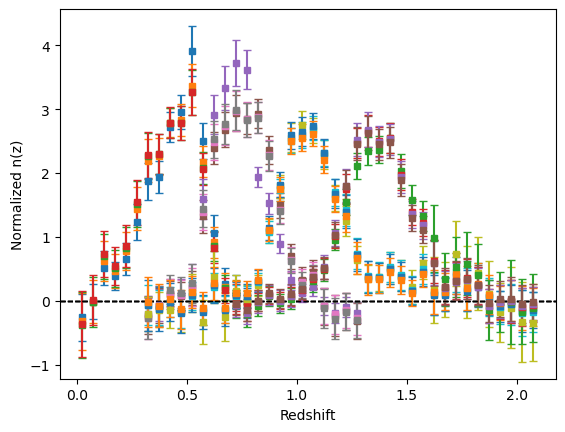

In [80]:
# renormalization and plotting
tbl = np.load(f"{RESULTS_ROOT}/merged_res_{scale_cut[0]}_{scale_cut[1]}_v3.npz")
print(tbl.files)
tomo_bins = [1,2,3,4]
bounds = {
    '1' : (0, 0.8),
    '2' : (0.3, 1.3),
    '3' : (0.3, 2.1),
    '4' : (0.7, 2.1)
}
norm_tbl = {}
for tomo in tomo_bins:
    for na in names:
        zn = tbl[f'{tomo}/{na}_z']
        z_mask = (zn >= bounds[str(tomo)][0]) & (zn <= bounds[str(tomo)][1])
        np_z = tbl[f'{tomo}/{na}'][z_mask]
        np_z_err = tbl[f'{tomo}/{na}_err'][z_mask]
        amplitude = np.trapezoid(np_z, zn[z_mask])
        
        norm_tbl[f'{tomo}/{na}_z'] = zn[z_mask]
        norm_tbl[f'{tomo}/{na}'] = np_z/amplitude
        norm_tbl[f'{tomo}/{na}_err'] = np_z_err/amplitude
        
        plt.errorbar(zn[z_mask], np_z/amplitude, np_z_err/amplitude, capsize=3, label=f'n(z) {na}', linestyle='', marker='s', ms=4)
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.grid()
    plt.xlabel('Redshift')
    plt.ylabel('Normalized n(z)')

if len(tomo_bins) == 1:
    plt.legend()

#np.savez_compressed(f"{RESULTS_ROOT}/merged_res_norm_{scale_cut[0]}_{scale_cut[1]}_v4.npz", **norm_tbl)

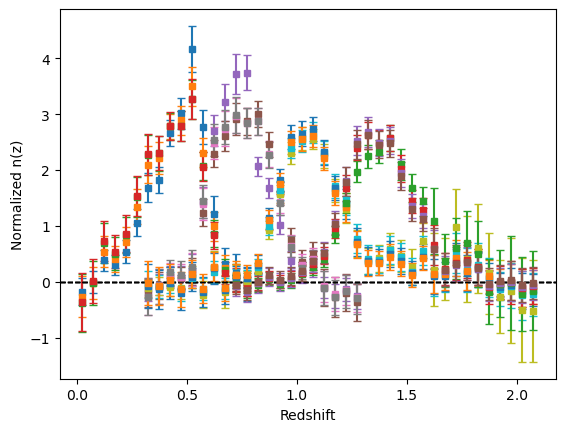

without QSO in bin 3 : 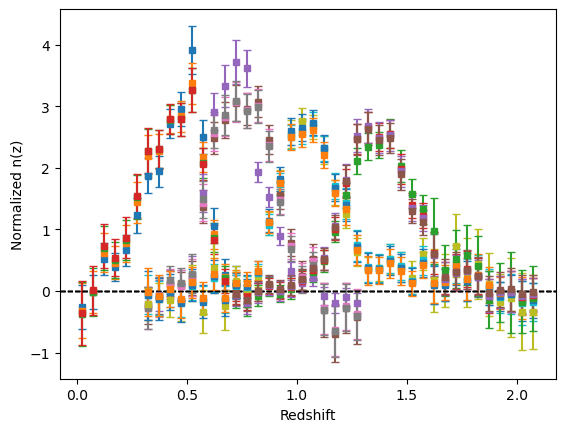

0.3, 3
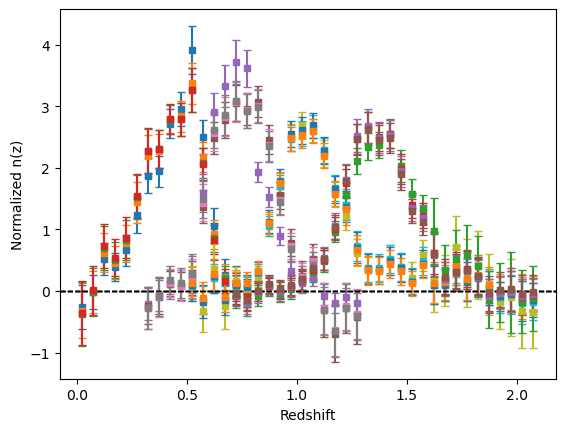

1,5
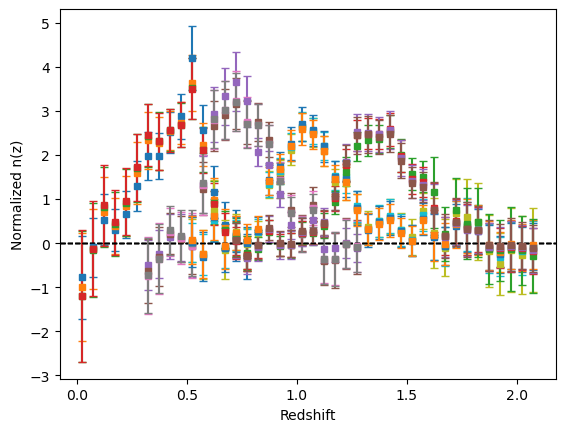

In [31]:
nt = np.load(f"{RESULTS_ROOT}/merged_res_norm_{scale_cut[0]}_{scale_cut[1]}_v3.npz")
nt.files

['1/npz_cross_z',
 '1/npz_cross',
 '1/npz_cross_err',
 '1/npz_bs_z',
 '1/npz_bs',
 '1/npz_bs_err',
 '1/npz_bs_bp_z',
 '1/npz_bs_bp',
 '1/npz_bs_bp_err',
 '1/npz_bs_bp_mag_z',
 '1/npz_bs_bp_mag',
 '1/npz_bs_bp_mag_err',
 '2/npz_cross_z',
 '2/npz_cross',
 '2/npz_cross_err',
 '2/npz_bs_z',
 '2/npz_bs',
 '2/npz_bs_err',
 '2/npz_bs_bp_z',
 '2/npz_bs_bp',
 '2/npz_bs_bp_err',
 '2/npz_bs_bp_mag_z',
 '2/npz_bs_bp_mag',
 '2/npz_bs_bp_mag_err',
 '3/npz_cross_z',
 '3/npz_cross',
 '3/npz_cross_err',
 '3/npz_bs_z',
 '3/npz_bs',
 '3/npz_bs_err',
 '3/npz_bs_bp_z',
 '3/npz_bs_bp',
 '3/npz_bs_bp_err',
 '3/npz_bs_bp_mag_z',
 '3/npz_bs_bp_mag',
 '3/npz_bs_bp_mag_err',
 '4/npz_cross_z',
 '4/npz_cross',
 '4/npz_cross_err',
 '4/npz_bs_z',
 '4/npz_bs',
 '4/npz_bs_err',
 '4/npz_bs_bp_z',
 '4/npz_bs_bp',
 '4/npz_bs_bp_err',
 '4/npz_bs_bp_mag_z',
 '4/npz_bs_bp_mag',
 '4/npz_bs_bp_mag_err']